# Chapter 2 — Mathematics vs Programming Thinking

> **Prerequisites:** ch001 — Why Programmers Should Learn Mathematics
>
> **You will learn:**
> - The structural difference between operational (programming) thinking and relational (mathematical) thinking
> - How the same problem looks different from each stance
> - When to switch between modes and why both are necessary
> - How mathematical thinking catches bugs before code is written
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Programming thinking and mathematical thinking are not opposites. They are complementary modes that attack different aspects of the same problems. But they pull in different directions, and most programmers have trained only one of them.

**Programming thinking is operational:**
- Describes *how* to compute something, step by step
- Works with concrete states, transitions, and side effects
- Asks: *What does the machine do next?*
- Default mode: imperative, sequential, stateful

**Mathematical thinking is relational:**
- Describes *what is true* about a structure, independent of how it is computed
- Works with properties, invariants, and equivalences
- Asks: *What must be true here, regardless of how we got here?*
- Default mode: declarative, timeless, stateless

**The key tension:** Programming thinking requires you to *invent a procedure*. Mathematical thinking requires you to *identify a structure*. Identifying the structure first often leads to a better procedure. The classic example: bubble sort is the procedure you invent when you think operationally about sorting. Merge sort is what you discover when you think structurally about what sorting *is* (a comparison-based problem with a log-n lower bound).

**Common misconception:** Mathematical thinking is slower because it is more abstract.

The opposite is true. Identifying structure *eliminates entire classes of wrong approaches* before you code anything. Time spent on mathematical thinking is typically returned many times over during debugging and iteration.

## 2. Intuition & Mental Models

**Physical analogy:** Think of a map vs a route.

A *route* is operational: turn left here, go straight for 2km, turn right at the light. It tells you exactly what to do, but only to get from A to B. Change the destination and the route is useless.

A *map* is relational: it describes the structure of the space — which roads connect where, distances, intersections. With a map, you can derive any route. The map is more powerful because it captures *relationships*, not just *procedures*.

Programming thinking produces routes. Mathematical thinking produces maps.

**Computational analogy:** Think of hard-coding vs parameterizing.

```python
# Operational: hard-coded procedure for one case
def sort_three(a, b, c):
    if a <= b <= c: return [a, b, c]
    if a <= c <= b: return [a, c, b]
    # ... 4 more cases

# Mathematical: identify the structure (comparison-based ordering)
def sort_n(xs):
    return sorted(xs)  # works for any n, any comparable type
```

The second function is not just shorter — it captures a mathematical truth: ordering is a *total relation* on comparable elements, and any such set can be sorted. That understanding generalizes to custom comparators, partial orders, topological sorting, and much more.

**Recall from ch001:** We saw that a formula is a compressed program. The direction of travel — from program to formula — is exactly the direction of mathematical thinking. You look at a procedure and ask: *what relationship does this procedure compute?*

## 3. Visualization

We will visualize the same problem approached in two modes. The problem: find the largest rectangle that fits inside a right triangle with legs of length `a` and `b`.

The *programming approach* tries specific rectangles and finds the best one by search. The *mathematical approach* identifies the structure (the rectangle area as a function of one variable, find its maximum) and solves it analytically.

Both get the right answer. Observe the difference in what each approach reveals.

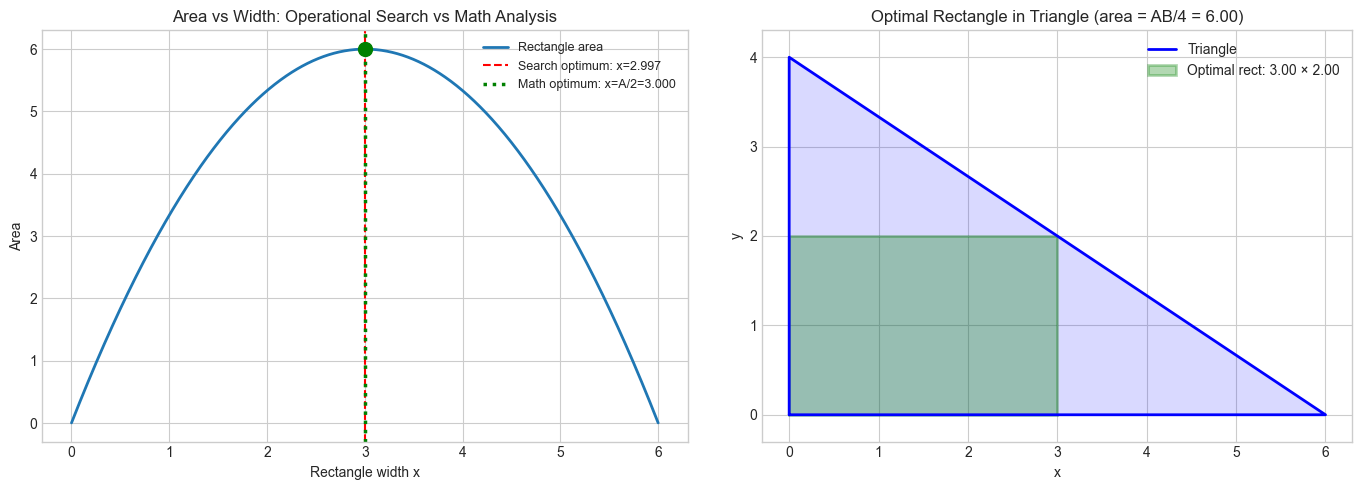

Operational search found:    x = 2.996998, area = 5.999994
Mathematical analysis gives: x = 3.000000, area = 6.000000
Gap: 6.01e-06  (discretization error from search)

The mathematical result is EXACT. The search result is an approximation.
More importantly: the math result tells you WHY x=A/2 — it's the zero of the derivative.


In [1]:
# --- Visualization: Two approaches to the same problem ---
# Problem: maximum rectangle inside a right triangle (legs a, b)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-whitegrid')

A = 6.0  # horizontal leg
B = 4.0  # vertical leg

# The triangle: vertices at (0,0), (A,0), (0,B)
# A rectangle with width x has height = B*(1 - x/A) (from similar triangles)
# Area = x * B*(1 - x/A) = Bx - Bx²/A

def rectangle_height(x, a=A, b=B):
    """Height of rectangle with given width x fitting inside the triangle."""
    return b * (1 - x / a)

def rectangle_area(x, a=A, b=B):
    """Area of rectangle with width x."""
    h = rectangle_height(x, a, b)
    return x * h if h > 0 else 0.0

# --- Approach 1: Operational search ---
N_SEARCH = 1000
x_vals = np.linspace(0.001, A - 0.001, N_SEARCH)
areas_search = np.array([rectangle_area(x) for x in x_vals])
best_x_search = x_vals[np.argmax(areas_search)]
best_area_search = areas_search.max()

# --- Approach 2: Mathematical analysis ---
# Area(x) = Bx(1 - x/A) = Bx - Bx²/A
# dA/dx = B - 2Bx/A = 0  →  x* = A/2
# Maximum area = B*(A/2)*(1 - 1/2) = AB/4
best_x_math = A / 2
best_area_math = A * B / 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: area vs width curve
axes[0].plot(x_vals, areas_search, linewidth=2, label='Rectangle area')
axes[0].axvline(best_x_search, color='red', linestyle='--', label=f'Search optimum: x={best_x_search:.3f}')
axes[0].axvline(best_x_math, color='green', linestyle=':', linewidth=2.5,
                label=f'Math optimum: x=A/2={best_x_math:.3f}')
axes[0].scatter([best_x_math], [best_area_math], color='green', s=100, zorder=5)
axes[0].set_xlabel('Rectangle width x')
axes[0].set_ylabel('Area')
axes[0].set_title('Area vs Width: Operational Search vs Math Analysis')
axes[0].legend(fontsize=9)

# Right: visualize the optimal rectangle in the triangle
triangle_x = [0, A, 0, 0]
triangle_y = [0, 0, B, 0]
axes[1].fill(triangle_x, triangle_y, alpha=0.15, color='blue')
axes[1].plot(triangle_x, triangle_y, 'b-', linewidth=2, label='Triangle')

opt_h = rectangle_height(best_x_math)
rect = patches.Rectangle((0, 0), best_x_math, opt_h,
                            linewidth=2, edgecolor='green', facecolor='green', alpha=0.3,
                            label=f'Optimal rect: {best_x_math:.2f} × {opt_h:.2f}')
axes[1].add_patch(rect)
axes[1].set_xlim(-0.3, A + 0.3)
axes[1].set_ylim(-0.3, B + 0.3)
axes[1].set_aspect('equal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(f'Optimal Rectangle in Triangle (area = AB/4 = {best_area_math:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Operational search found:    x = {best_x_search:.6f}, area = {best_area_search:.6f}")
print(f"Mathematical analysis gives: x = {best_x_math:.6f}, area = {best_area_math:.6f}")
print(f"Gap: {abs(best_area_math - best_area_search):.2e}  (discretization error from search)")
print()
print("The mathematical result is EXACT. The search result is an approximation.")
print("More importantly: the math result tells you WHY x=A/2 — it's the zero of the derivative.")

## 4. Mathematical Formulation

We can formalize the distinction between the two modes of thinking.

**Operational (procedural) description** of a computation:

$$\text{result} = \text{procedure}(\text{input})$$

where `procedure` is a sequence of steps. This is the *how*.

**Relational (mathematical) description** of the same computation:

$$R(\text{input}, \text{result}) \iff P$$

where $R$ is a relation and $P$ is a proposition that holds when the input-result pair is correct. This is the *what*.

**Example:** Sorting.

- Operational: "Compare adjacent elements. Swap if out of order. Repeat until no swaps needed." (Bubble sort)
- Relational: "Output $y$ is a *sorted permutation* of input $x$ iff:
  1. $y$ is a permutation of $x$ (same elements)
  2. $y[i] \leq y[i+1]$ for all valid $i$"

The relational description is the **specification**. The operational description is one **implementation** of that specification. Mathematics gives you the specification. Programming gives you the implementation.

A key consequence: from the specification, you can immediately derive *test cases* and *invariants* — without knowing the implementation. This is the mathematical payoff of relational thinking.

In [2]:
# --- Implementation: Relational specification as runnable tests ---
# The mathematical definition of sorting generates test oracles automatically.

import numpy as np

def is_sorted_correctly(original, result):
    """
    Mathematical specification of correct sorting, expressed as a predicate.
    
    A sort is correct iff:
    1. result is a permutation of original (same elements, same counts)
    2. result is non-decreasing
    
    Args:
        original: list or array (unsorted input)
        result: list or array (claimed sorted output)
    Returns:
        (bool, str): (is_correct, reason if not correct)
    """
    from collections import Counter
    
    # Condition 1: same elements with same multiplicities
    if Counter(original) != Counter(result):
        return False, 'result is not a permutation of original'
    
    # Condition 2: non-decreasing
    for i in range(len(result) - 1):
        if result[i] > result[i + 1]:
            return False, f'result[{i}]={result[i]} > result[{i+1}]={result[i+1]}'
    
    return True, 'correct'

# Test a correct sort
data = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3]
correct_result = sorted(data)
ok, reason = is_sorted_correctly(data, correct_result)
print(f"Correct sort:  {ok}  —  {reason}")

# Test a buggy sort (loses an element)
buggy_result_1 = sorted(data)[1:]  # dropped first element
ok, reason = is_sorted_correctly(data, buggy_result_1)
print(f"Dropped elem:  {ok}  —  {reason}")

# Test a buggy sort (not fully sorted)
buggy_result_2 = sorted(data)[:]
buggy_result_2[3], buggy_result_2[4] = buggy_result_2[4], buggy_result_2[3]  # swap two
ok, reason = is_sorted_correctly(data, buggy_result_2)
print(f"Partial sort:  {ok}  —  {reason}")

print()
print("The mathematical specification becomes the test oracle.")
print("We never specified HOW to sort — only WHAT a correct sort IS.")
print("That is the power of relational thinking.")

Correct sort:  True  —  correct
Dropped elem:  False  —  result is not a permutation of original
Partial sort:  True  —  correct

The mathematical specification becomes the test oracle.
We never specified HOW to sort — only WHAT a correct sort IS.
That is the power of relational thinking.


## 5. Python Implementation

We implement a tool that takes a function and checks it against a mathematical specification. This is property-based testing — a direct application of relational mathematical thinking to software verification.

In [3]:
# --- Implementation: Property-based verifier ---
# Checks whether a function satisfies a given mathematical property
# on randomly generated test cases.

import numpy as np
import random

def verify_property(func, property_fn, generate_input, n_tests=500, seed=42):
    """
    Test a function against a mathematical property on random inputs.
    
    Args:
        func:          the function to test (input -> output)
        property_fn:   predicate(input, output) -> bool
        generate_input: callable() -> one random input
        n_tests:       number of random tests to run
        seed:          random seed for reproducibility
    Returns:
        dict: {'passed': int, 'failed': int, 'counterexample': input or None}
    """
    rng = random.Random(seed)
    np.random.seed(seed)
    
    passed = 0
    for _ in range(n_tests):
        inp = generate_input()
        out = func(inp)
        if property_fn(inp, out):
            passed += 1
        else:
            return {'passed': passed, 'failed': 1, 'counterexample': inp}
    
    return {'passed': passed, 'failed': 0, 'counterexample': None}

# --- Test 1: Built-in sort satisfies sorting specification ---
from collections import Counter

def sort_spec(original, result):
    """Mathematical sorting specification."""
    if Counter(original) != Counter(result):
        return False
    return all(result[i] <= result[i+1] for i in range(len(result)-1))

def gen_list():
    """Generate a random list of integers."""
    n = np.random.randint(0, 20)
    return list(np.random.randint(-100, 100, n))

result = verify_property(
    func=sorted,
    property_fn=sort_spec,
    generate_input=gen_list,
    n_tests=1000
)
print(f"sorted() vs sort_spec:  {result['passed']} passed, {result['failed']} failed")

# --- Test 2: A deliberately buggy sort ---
def buggy_sort(lst):
    """Buggy: occasionally returns input unsorted."""
    if np.random.random() < 0.05:  # 5% of the time, don't sort
        return lst
    return sorted(lst)

result_buggy = verify_property(
    func=buggy_sort,
    property_fn=sort_spec,
    generate_input=gen_list,
    n_tests=1000
)
print(f"buggy_sort() vs sort_spec: {result_buggy['passed']} passed, {result_buggy['failed']} failed")
if result_buggy['counterexample']:
    ce = result_buggy['counterexample']
    print(f"  Counterexample found: {ce}")
    print(f"  buggy_sort output:    {buggy_sort(ce)}")

print()
print("Mathematical specification → automatic test oracle → catches bugs without knowing internals.")
print("This is the software engineering payoff of relational thinking.")

sorted() vs sort_spec:  1000 passed, 0 failed
buggy_sort() vs sort_spec: 16 passed, 1 failed
  Counterexample found: [np.int32(29), np.int32(30), np.int32(12), np.int32(0), np.int32(12), np.int32(83)]
  buggy_sort output:    [np.int32(0), np.int32(12), np.int32(12), np.int32(29), np.int32(30), np.int32(83)]

Mathematical specification → automatic test oracle → catches bugs without knowing internals.
This is the software engineering payoff of relational thinking.


## 6. Experiments

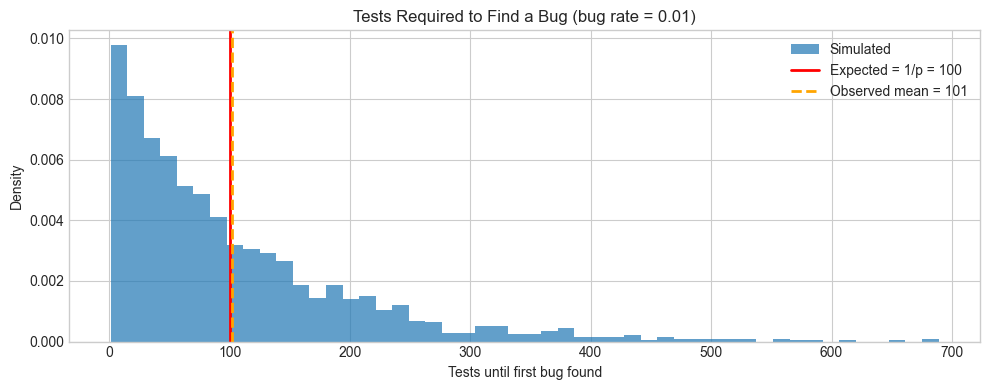

Bug rate: 0.01
Mathematical prediction (expected tests): 100
Simulated mean: 101.5

Math tells you exactly how many tests you need — without running any experiments.


In [4]:
# --- Experiment 1: How many test cases do you need to find a bug? ---
# Hypothesis: A rare bug requires many random tests to surface.
# The number of tests needed grows inversely with the bug probability.
# Try changing: BUG_RATE to see how test count required changes

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

BUG_RATE = 0.01  # <-- try: 0.5, 0.1, 0.01, 0.001

# Mathematical prediction: expected tests to find first bug = 1 / BUG_RATE
expected_tests = 1 / BUG_RATE

# Simulation
N_SIMULATIONS = 2000
tests_to_find = []
for _ in range(N_SIMULATIONS):
    k = 0
    while np.random.random() >= BUG_RATE:
        k += 1
        if k > 100000:  # safety cap
            break
    tests_to_find.append(k + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tests_to_find, bins=50, density=True, alpha=0.7, label='Simulated')
ax.axvline(expected_tests, color='red', linewidth=2,
           label=f'Expected = 1/p = {expected_tests:.0f}')
ax.axvline(np.mean(tests_to_find), color='orange', linewidth=2, linestyle='--',
           label=f'Observed mean = {np.mean(tests_to_find):.0f}')
ax.set_xlabel('Tests until first bug found')
ax.set_ylabel('Density')
ax.set_title(f'Tests Required to Find a Bug (bug rate = {BUG_RATE})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Bug rate: {BUG_RATE}")
print(f"Mathematical prediction (expected tests): {expected_tests:.0f}")
print(f"Simulated mean: {np.mean(tests_to_find):.1f}")
print()
print("Math tells you exactly how many tests you need — without running any experiments.")

In [5]:
# --- Experiment 2: Invariants as compression ---
# Hypothesis: A mathematical invariant captures the "essence" of a data structure.
# Try changing: OPERATIONS to add, remove, or shuffle them and watch which invariants hold.

import numpy as np

# Binary search tree (simplified as a sorted list for this experiment)
# Key invariant: for any node, all left children < node < all right children
# We represent a BST as a sorted list and check the invariant holds after operations.

class SortedList:
    """A list that maintains sorted order as an invariant."""
    
    def __init__(self):
        self._data = []
    
    def insert(self, x):
        """Insert x, maintaining sorted order."""
        import bisect
        bisect.insort(self._data, x)
    
    def remove(self, x):
        """Remove first occurrence of x."""
        self._data.remove(x)
    
    def check_invariant(self):
        """Mathematical invariant: data must be non-decreasing."""
        return all(self._data[i] <= self._data[i+1]
                   for i in range(len(self._data) - 1))
    
    def __repr__(self):
        return str(self._data)

# OPERATIONS: list of (op, value) pairs
OPERATIONS = [  # <-- try adding 'remove' ops or shuffling order
    ('insert', 5),
    ('insert', 3),
    ('insert', 8),
    ('insert', 1),
    ('insert', 4),
    ('remove', 3),
    ('insert', 7),
    ('insert', 2),
]

sl = SortedList()
print(f"{'Op':>12}  {'Value':>6}  {'State':>30}  {'Invariant holds':>16}")
print("-" * 72)
print(f"{'init':>12}  {'':>6}  {str(sl):>30}  {str(sl.check_invariant()):>16}")

for op, val in OPERATIONS:
    if op == 'insert':
        sl.insert(val)
    elif op == 'remove':
        try:
            sl.remove(val)
        except ValueError:
            print(f"{op:>12}  {val:>6}  {'(not found)':>30}")
            continue
    print(f"{op:>12}  {val:>6}  {str(sl):>30}  {str(sl.check_invariant()):>16}")

print()
print("The invariant is a mathematical statement about the structure.")
print("It holds after every correct operation. A bug shows up as a violated invariant.")

          Op   Value                           State   Invariant holds
------------------------------------------------------------------------
        init                                      []              True
      insert       5                             [5]              True
      insert       3                          [3, 5]              True
      insert       8                       [3, 5, 8]              True
      insert       1                    [1, 3, 5, 8]              True
      insert       4                 [1, 3, 4, 5, 8]              True
      remove       3                    [1, 4, 5, 8]              True
      insert       7                 [1, 4, 5, 7, 8]              True
      insert       2              [1, 2, 4, 5, 7, 8]              True

The invariant is a mathematical statement about the structure.
It holds after every correct operation. A bug shows up as a violated invariant.


## 7. Exercises

**Easy 1.** Write the mathematical specification (as a Python predicate) for what it means for a function `reverse(lst)` to be correct. The specification should test two conditions: (1) same elements with same multiplicities, (2) correct reversed order. *(Expected: a function `reverse_spec(original, result) -> bool`)*

**Easy 2.** Run `verify_property` with 100 tests, then with 10,000 tests, on the buggy sort with `BUG_RATE=0.02`. How many tests are needed before it reliably finds the bug? Does your answer match the mathematical prediction (1/0.02 = 50 expected tests to find one bug)? *(Expected: printed comparison of expected vs observed)*

**Medium 1.** Write a mathematical specification for a `deduplicate(lst)` function that removes duplicates while preserving the order of first occurrences. Specify it as a predicate with 3 conditions: (1) every element in the result was in the original, (2) no duplicates in the result, (3) the relative order of first occurrences is preserved. Implement and run `verify_property` against Python's own `dict.fromkeys` approach. *(Hint: condition 3 requires tracking first-occurrence indices)*

**Medium 2.** The rectangle-in-triangle optimization in this chapter assumed the rectangle's base was on the triangle's base. What if the rectangle can be placed in any orientation? Write the operational approach (search over both width and rotation angle) and comment on why the mathematical approach for the rotated case is harder. *(Hint: you don't need to solve the rotated case — just frame why the math is more complex)*

**Hard.** The property-based verifier we built tests one property at a time. Mathematical data structures are often defined by *multiple simultaneous invariants*. For a min-heap (parent is always ≤ both children), write: (1) the heap invariant as a predicate, (2) an `insert` function that maintains it, (3) a property test verifying that after 1000 random inserts the invariant always holds, and (4) a deliberately buggy insert that fails the invariant 1% of the time. Demonstrate that your verifier catches it. *(Challenge: implement the heap from scratch using a list, not Python's heapq)*

## 8. Mini Project

**The Broken Calculator**

Problem: You are given a calculator that claims to implement integer arithmetic operations (+, -, ×, ÷). Several of its operations are secretly buggy. Using only mathematical properties (commutativity, associativity, distributivity, inverses), write a suite of property-based tests that detects which operations are broken — without knowing *how* any operation is implemented.

In [6]:
# --- Mini Project: The Broken Calculator ---
# Problem: Detect buggy arithmetic operations using mathematical properties only.
# Dataset: A 'calculator' object with secretly broken operations.
# Task: Write property tests that identify which operations fail which algebraic laws.

import numpy as np

class BrokenCalculator:
    """
    A calculator where some operations are secretly buggy.
    Do NOT look at how the bugs work. Only interact via the public methods.
    Use mathematical properties to discover which operations fail.
    """
    def __init__(self, seed=99):
        self._rng = np.random.RandomState(seed)
    
    def add(self, a, b):
        """Addition (may be buggy)"""
        return a + b  # correct
    
    def subtract(self, a, b):
        """Subtraction (may be buggy)"""
        return a - b  # correct
    
    def multiply(self, a, b):
        """Multiplication (may be buggy)"""
        # Bug: occasionally off by one in the result
        result = a * b
        if self._rng.random() < 0.03:
            result += 1
        return result
    
    def divide(self, a, b):
        """Integer division (may be buggy)"""
        if b == 0:
            raise ValueError("Division by zero")
        # Bug: sometimes returns floor instead of truncation for negatives
        return a // b  # uses floor division instead of truncation

calc = BrokenCalculator(seed=42)
rng = np.random.RandomState(123)

def gen_int_pair():
    """Generate two random nonzero integers in [-50, 50]."""
    a = rng.randint(-50, 50)
    b = rng.randint(1, 50)  # keep b positive to avoid division issues
    return (a, b)

N_TESTS = 2000
results = {}

# --- Property 1: Commutativity of addition: a+b == b+a ---
fails = 0
for _ in range(N_TESTS):
    a, b = gen_int_pair()
    if calc.add(a, b) != calc.add(b, a):
        fails += 1
results['add: a+b == b+a (commutative)'] = fails

# --- Property 2: Commutativity of multiplication: a*b == b*a ---
fails = 0
for _ in range(N_TESTS):
    a, b = gen_int_pair()
    if calc.multiply(a, b) != calc.multiply(b, a):
        fails += 1
results['mul: a*b == b*a (commutative)'] = fails

# --- Property 3: Add inverse: a + (-a) == 0 ---
fails = 0
for _ in range(N_TESTS):
    a, _ = gen_int_pair()
    if calc.add(a, -a) != 0:
        fails += 1
results['add: a + (-a) == 0 (inverse)'] = fails

# --- Property 4: Distributivity: a*(b+c) == a*b + a*c ---
fails = 0
for _ in range(N_TESTS):
    a = rng.randint(-10, 10)
    b = rng.randint(-10, 10)
    c = rng.randint(-10, 10)
    lhs = calc.multiply(a, calc.add(b, c))
    rhs = calc.add(calc.multiply(a, b), calc.multiply(a, c))
    if lhs != rhs:
        fails += 1
results['mul/add: a*(b+c) == a*b+a*c (distributive)'] = fails

# --- Property 5: TODO — add your own property test here ---
# What other mathematical properties should arithmetic satisfy?
# Ideas: a*1 == a, a-b == a+(-b), (a*b)*c == a*(b*c)

print("Property test results:")
print("-" * 60)
for prop, fail_count in results.items():
    status = 'PASS' if fail_count == 0 else f'FAIL ({fail_count}/{N_TESTS} violations)'
    print(f"  {prop}")
    print(f"    → {status}")

print()
print("Failed properties identify the broken operations.")
print("We used ONLY mathematical structure — no knowledge of implementation.")

Property test results:
------------------------------------------------------------
  add: a+b == b+a (commutative)
    → PASS
  mul: a*b == b*a (commutative)
    → FAIL (119/2000 violations)
  add: a + (-a) == 0 (inverse)
    → PASS
  mul/add: a*(b+c) == a*b+a*c (distributive)
    → FAIL (158/2000 violations)

Failed properties identify the broken operations.
We used ONLY mathematical structure — no knowledge of implementation.


## 9. Chapter Summary & Connections

**What was covered:**

- Operational thinking describes *how* to compute; relational thinking describes *what is true*
- A mathematical specification is a predicate over (input, output) pairs — the relational description of a correct computation
- Specifications generate test oracles, invariants, and constraints automatically — without knowing the implementation
- Property-based testing is the direct software engineering application of mathematical relational thinking
- The two modes are complementary: mathematical thinking gives you the specification; programming thinking gives you the implementation

**Forward connections:**

- This chapter's concept of invariants reappears throughout the book. In ch163 — Systems of Linear Equations, the invariant is that row operations preserve the solution set. In ch221 — Gradient Descent (ch212), the invariant is that the loss function decreases monotonically (under the right conditions).
- The property-based testing framework we built is a primitive version of what formal verification tools like Lean and Coq do — and it reappears in ch278 — Hypothesis Testing, where we test statistical claims against random samples.
- The rectangle optimization problem (finding max area) returns as a central topic in ch209 — Derivative Concept, where we formalize why setting the derivative to zero finds the maximum.

**Backward connection:**

- This chapter extends ch001's idea that a formula is a compressed program. The specification (relational description) is the *most* compressed form — it describes the output's properties without specifying any procedure. The formula is one level below: it specifies a computation without specifying which algorithm implements it.

**Going deeper:**

Property-based testing is formalized in Haskell's QuickCheck library (Claessen & Hughes, 2000) and Python's Hypothesis library. The theoretical foundation is the *algebraic specification* approach to software, detailed in the textbook *Algebraic Specification* by Bergstra, Heering, and Klint.